# Import Libraries

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import f_oneway, chi2_contingency
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier


# Step 1: Load the Data & Look Around

In [2]:
df = pd.read_csv('/kaggle/input/datasets/mobeenfatimah/mental-health-and-burnout-prediction-dataset/mental_health_burnout_prediction_dataset.csv')

## Perform Basic Checks

In [3]:
def basic_checks(df):
    print('-'*40, 'SHAPE', '-'*40)
    print(df.shape)
    print('-'*40, 'HEAD', '-'*40)
    print(df.head(10))
    print('-'*40, 'COLUMN DATA TYPES', '-'*40)
    print(df.info())
    print('-'*40, 'NUMERICAL STATISTICS', '-'*40)
    print(df.describe().T)
    print('-'*40, 'CATEGORICAL STATISTICS', '-'*40)
    print(df.describe(include='object').T)
    print('-'*40, 'MISSING VALUES', '-'*40)
    print(df.isnull().sum().sort_values(ascending=False))


In [4]:
basic_checks(df)

---------------------------------------- SHAPE ----------------------------------------
(50000, 40)
---------------------------------------- HEAD ----------------------------------------
   Person_ID   Age  Gender        Country         Occupation Education_Level  \
0          1  58.0    Male  United States  Marketing Manager         Diploma   
1          2  24.0  Female       Pakistan         Freelancer        Bachelor   
2          3  59.0    Male       Malaysia         Accountant             PhD   
3          4  65.0   Other         Mexico               Chef          Master   
4          5  64.0   Other          Japan             Farmer         Diploma   
5          6  48.0   Other          Italy  Marketing Manager             PhD   
6          7  33.0  Female        Nigeria     Police Officer         Diploma   
7          8  22.0  Female      Singapore              Nurse     High School   
8          9  50.0   Other          Italy            Teacher             PhD   
9         10 

## Target Variable and Data Leakage

The target variable for this project is `Burnout_Risk`.

`Burnout_Risk` is a multiclass classification target representing an individual's
burnout risk level.

Before modeling, the following columns will be excluded from the feature set:

- `Burnout_Score` — directly used to derive `Burnout_Risk`, creating target leakage.
- `Mental_Health_Status` — derived from the same underlying burnout information.
- `AI_Wellness_Recommendation` — appears to be generated based on the individual's
  assessed condition and therefore would not represent an independent predictor.
- `Person_ID` — an identifier with no meaningful predictive information.

These variables will not be available to the model when predicting burnout risk.
Removing them helps ensure that the model learns meaningful relationships from
potential risk factors rather than simply learning information derived from the
target.

# Step 2: Pre-Cleaning Data Quality Checks

### Missing values, duplicates, and target distribution

In [5]:
# 1. Missing values
print('Missing Values:')
display(df.isnull().sum().sort_values(ascending=False))

missing_pct = df.isnull().mean()*100
print('Missing Values Percentage:')
display(missing_pct.sort_values(ascending=False))

# 2. Duplicate Rows
print('Duplicates:')
display(df.duplicated().sum())

# 3. Target Distribution
print('Burnout Risk Distribution')
display(df['Burnout_Risk'].value_counts())

print('Burnout Risk Distribution Percentage')
display(df['Burnout_Risk'].value_counts(normalize=True).mul(100).round(2))

Missing Values:


Monthly_Income_USD               1450
Meditation_Minutes               1200
Physical_Activity_Hours          1100
Sleep_Hours                       950
Productivity_Score                950
Mood_Score                        900
Depression_Score                  850
Screen_Time_Hours                 850
Anxiety_Score                     800
Gaming_Hours                      750
Life_Satisfaction                 700
Work_Life_Balance                 650
Social_Media_Hours                600
Job_Satisfaction                  500
Therapy_Attendance                400
Age                               250
Employment_Status                   0
Education_Level                     0
Occupation                          0
Country                             0
Person_ID                           0
Gender                              0
Remote_Work                         0
Work_Hours_Per_Week                 0
Exercise_Frequency                  0
Emotional_Stability                 0
Sleep_Qualit

Missing Values Percentage:


Monthly_Income_USD               2.9
Meditation_Minutes               2.4
Physical_Activity_Hours          2.2
Sleep_Hours                      1.9
Productivity_Score               1.9
Mood_Score                       1.8
Depression_Score                 1.7
Screen_Time_Hours                1.7
Anxiety_Score                    1.6
Gaming_Hours                     1.5
Life_Satisfaction                1.4
Work_Life_Balance                1.3
Social_Media_Hours               1.2
Job_Satisfaction                 1.0
Therapy_Attendance               0.8
Age                              0.5
Employment_Status                0.0
Education_Level                  0.0
Occupation                       0.0
Country                          0.0
Person_ID                        0.0
Gender                           0.0
Remote_Work                      0.0
Work_Hours_Per_Week              0.0
Exercise_Frequency               0.0
Emotional_Stability              0.0
Sleep_Quality                    0.0
S

Duplicates:


np.int64(0)

Burnout Risk Distribution


Burnout_Risk
Low         25369
Moderate    14780
High         9851
Name: count, dtype: int64

Burnout Risk Distribution Percentage


Burnout_Risk
Low         50.74
Moderate    29.56
High        19.70
Name: proportion, dtype: float64

### Check for obviously invalid values

In [6]:
# Numerical Columns
num_cols = df.select_dtypes(include='number').columns

# Basic minimum and maximum values
range_check = df[num_cols].agg(['min', 'max']).T
display(range_check)

,min,max
Person_ID,1.0,50000.0
Age,18.0,65.0
Monthly_Income_USD,500.0,12000.0
Work_Hours_Per_Week,20.0,70.0
Job_Satisfaction,1.0,10.0
Work_Life_Balance,1.0,10.0
Sleep_Hours,4.0,10.0
Anxiety_Score,0.0,100.0
Depression_Score,0.0,100.0
Mood_Score,0.0,100.0


In [7]:
# Check for potentially invalid values

checks = {
    'Age': (df['Age'] <= 0).sum(),
    'Sleep_Hours': (df['Sleep_Hours'] < 0).sum(),
    'Job_Satisfaction': ((df['Job_Satisfaction'] < 1) | (df['Job_Satisfaction'] > 10)).sum(),
    'Work_Life_Balance': ((df['Work_Life_Balance'] < 1) | (df['Work_Life_Balance'] > 10)).sum(),
    'Burnout_Score': ((df['Burnout_Score'] < 0) | (df['Burnout_Score'] > 100)).sum()
}

invalid_values = pd.Series(checks, name='Invalid Count')
display(invalid_values)


Age                  0
Sleep_Hours          0
Job_Satisfaction     0
Work_Life_Balance    0
Burnout_Score        0
Name: Invalid Count, dtype: int64

## Explanation

Before performing any cleaning or preprocessing, the dataset was checked for missing values, duplicate records, target distribution, and values outside the valid ranges defined in the Data Dictionary.

### Missing Values

- 16 columns contain missing values.
- Missing values occur in numerical wellbeing, lifestyle, work, and mental-health-related variables, as well as `Therapy_Attendance`.
- The target variable, `Burnout_Risk`, contains no missing values.

### Duplicate Records

- Duplicate rows: **0**
- No duplicate records were identified in the dataset.

### Target Distribution

The target variable, `Burnout_Risk`, has three classes:

- **Low:** approximately 51%
- **Moderate:** approximately 30%
- **High:** approximately 20%

The target distribution is moderately imbalanced, with `Low` burnout risk representing the majority class. Therefore, model evaluation should not rely solely on accuracy, and metrics such as precision, recall, and F1-score will also be considered.

### Scale and Range Validation

Only variables with explicitly defined valid ranges in the Data Dictionary were checked for invalid values.

The following checks found **0 invalid values**:

- `Age`
- `Sleep_Hours`
- `Job_Satisfaction`
- `Work_Life_Balance`
- `Burnout_Score`

Based on the scale validation checks, no obvious out-of-range values were identified in these variables.

### Summary

The dataset contains missing values that will require preprocessing, but no duplicate rows or obvious invalid values were identified in the variables checked against their defined scales. No data has been modified at this stage. These findings will guide the data cleaning and preprocessing steps later in the project.

# Step 3: Clean the Data

In [8]:
# Select both object and category types
cat_cols = df.select_dtypes(include=["object", "category"]).columns

# Display unique values for each categorical column
for col in cat_cols:
    print('-'*40, col, '-'*40)
    print(df[col].value_counts(dropna=False))


---------------------------------------- Gender ----------------------------------------
Gender
Female    16810
Male      16681
Other     16509
Name: count, dtype: int64
---------------------------------------- Country ----------------------------------------
Country
South Africa            2098
Canada                  2061
Russia                  2051
Saudi Arabia            2043
Pakistan                2039
Spain                   2031
Turkey                  2030
South Korea             2029
France                  2021
United States           2014
Mexico                  2010
Germany                 2003
Egypt                   2003
Japan                   1999
Singapore               1989
India                   1985
Australia               1985
United Kingdom          1983
Indonesia               1975
Malaysia                1974
United Arab Emirates    1960
China                   1951
Nigeria                 1946
Brazil                  1915
Italy                   1905
Name: c

### Handle Missing Values

In [9]:
# Numerical Columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Categorical columns
df['Therapy_Attendance'] = df['Therapy_Attendance'].fillna('Unknown')

# # Confirm missing values have been handled
display(df.isnull().sum())

Person_ID                        0
Age                              0
Gender                           0
Country                          0
Occupation                       0
Education_Level                  0
Employment_Status                0
Monthly_Income_USD               0
Work_Hours_Per_Week              0
Remote_Work                      0
Job_Satisfaction                 0
Work_Life_Balance                0
Sleep_Hours                      0
Sleep_Quality                    0
Stress_Level                     0
Anxiety_Score                    0
Depression_Score                 0
Mood_Score                       0
Emotional_Stability              0
Physical_Activity_Hours          0
Exercise_Frequency               0
Meditation_Minutes               0
Screen_Time_Hours                0
Social_Media_Hours               0
Gaming_Hours                     0
Coffee_Cups_Per_Day              0
Alcohol_Consumption              0
Smoking                          0
Healthy_Diet        

In [10]:
# Display all data types
print('-'*40, 'COLUMN DATA TYPES', '-'*40)
print(df.info())

---------------------------------------- COLUMN DATA TYPES ----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 40 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Person_ID                      50000 non-null  int64  
 1   Age                            50000 non-null  float64
 2   Gender                         50000 non-null  object 
 3   Country                        50000 non-null  object 
 4   Occupation                     50000 non-null  object 
 5   Education_Level                50000 non-null  object 
 6   Employment_Status              50000 non-null  object 
 7   Monthly_Income_USD             50000 non-null  float64
 8   Work_Hours_Per_Week            50000 non-null  int64  
 9   Remote_Work                    50000 non-null  object 
 10  Job_Satisfaction               50000 non-null  float64
 11  Work_L

In [11]:
# Final data quality checks

print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

print("\nInvalid value checks:")

invalid_values = pd.Series(checks, name='Invalid Count')
display(invalid_values)

Missing values: 0
Duplicate rows: 0

Invalid value checks:


Age                  0
Sleep_Hours          0
Job_Satisfaction     0
Work_Life_Balance    0
Burnout_Score        0
Name: Invalid Count, dtype: int64

## Explanation
The dataset was cleaned after completing the pre-cleaning quality checks.

### Missing Values

Missing numerical values were handled using **median imputation**. The median was selected because it is less sensitive to extreme values than the mean and provides a robust default for variables such as income, sleep, activity, and mental-health scores.

For the categorical variable `Therapy_Attendance`, missing values were replaced with **`Unknown`** rather than the mode. This preserves the fact that the person's therapy attendance status was not recorded rather than assuming that they belong to the most common category.

After imputation:

- Total missing values: **0**

### Categorical Variables

The categorical variables were inspected for inconsistent or duplicated labels.

No obvious inconsistencies were identified. Categories such as `Yes`/`No`, `Low`/`Moderate`/`High`, and the other categorical values were consistently formatted.

Therefore, no category-label standardization was required.

### Data Types

The data types were reviewed after cleaning.

The main count-based variables retained integer data types, including:

- `Work_Hours_Per_Week`
- `Coffee_Cups_Per_Day`
- `Absenteeism_Days`
- `Burnout_Score`

Continuous numerical variables such as `Age`, `Monthly_Income_USD`, `Sleep_Hours`, and the various wellbeing scores are represented as `float64`, which is appropriate after median imputation.

Categorical variables remain as `object` and will be encoded during the machine-learning preprocessing stage.

### Final Data Quality Check

The original data-quality issues were rechecked after cleaning:

- Missing values: **0**
- Duplicate rows: **0**
- Invalid `Age` values: **0**
- Invalid `Sleep_Hours` values: **0**
- Invalid `Job_Satisfaction` values: **0**
- Invalid `Work_Life_Balance` values: **0**
- Invalid `Burnout_Score` values: **0**

The dataset is therefore ready for exploratory analysis and statistical hypothesis testing.

> **Note:** During the final machine-learning pipeline, imputation and encoding will be performed within a scikit-learn preprocessing pipeline to prevent data leakage between training and testing data.

# Step 4: Hypothesis Testing

### ANOVA (3 target groups)

In [12]:
# Create Sleep_Hours 
# Split Sleep_Hours into the three burnout-risk groups
low = df[df['Burnout_Risk'] == 'Low']['Sleep_Hours']
moderate = df[df['Burnout_Risk'] == 'Moderate']['Sleep_Hours']
high = df[df['Burnout_Risk'] == 'High']['Sleep_Hours']

# One-way ANOVA
f_stat, p_value = f_oneway(low, moderate, high)

print(f"F-statistic: {f_stat:.4f}")
print(f"p-value: {p_value:.6f}")


F-statistic: 962.9559
p-value: 0.000000


In [13]:
# Create a loop for all 4 numeric features
num_features = ["Sleep_Hours", "Work_Hours_Per_Week", "Job_Satisfaction", "Work_Life_Balance"]

anova_results = []

for feature in num_features:
    g_low = df[df["Burnout_Risk"] == "Low"][feature]
    g_mod = df[df["Burnout_Risk"] == "Moderate"][feature]
    g_high = df[df["Burnout_Risk"] == "High"][feature]
    
  
    f_stat, p_val = f_oneway(g_low, g_mod, g_high)
    
 
    anova_results.append({
        "Feature": feature,
        "F-statistic": f_stat,
        "p-value": f"{p_val:.6f}",
        "Significant": p_val < 0.05
    })

display(pd.DataFrame(anova_results))


,Feature,F-statistic,p-value,Significant
0,Sleep_Hours,962.955900,0.000000,True
1,Work_Hours_Per_Week,11146.021254,0.000000,True
2,Job_Satisfaction,0.198531,0.819935,False
3,Work_Life_Balance,0.581440,0.559097,False


### ANOVA Results

One-way ANOVA was used to determine whether the mean values of selected numerical features differed significantly across the three `Burnout_Risk` groups: Low, Moderate, and High.

### Hypotheses

* **H₀ (Null Hypothesis):** The mean value of the feature is the same across all three burnout-risk groups.
* **H₁ (Alternative Hypothesis):** At least one burnout-risk group has a different mean value.

A significance level of **α = 0.05** was used.

### Results

| Feature             | F-statistic | p-value | Significant |
| ------------------- | ----------: | ------: | ----------- |
| Sleep_Hours         |     962.956 | < 0.001 | Yes         |
| Work_Hours_Per_Week |  11,146.021 | < 0.001 | Yes         |
| Job_Satisfaction    |       0.199 |   0.820 | No          |
| Work_Life_Balance   |       0.581 |   0.559 | No          |

### Interpretation

The ANOVA results indicate statistically significant differences in **Sleep_Hours** and **Work_Hours_Per_Week** across the burnout-risk groups. Therefore, the null hypothesis is rejected for these two features.

For **Job_Satisfaction** and **Work_Life_Balance**, the p-values are greater than 0.05, so there is insufficient evidence to reject the null hypothesis.

These results indicate statistical associations with burnout-risk group membership rather than causal relationships. The ANOVA test also does not identify which specific groups differ from each other; that would require an appropriate post-hoc test.


### Chi-square tests

In [14]:
cat_features = ['Stress_Level', 'Support_System', 'Chronic_Stress', 'Therapy_Attendance']

chi2_results = []

for feature in cat_features:
    contingency_table = pd.crosstab(df[feature],df['Burnout_Risk'])
    
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    
    chi2_results.append({
        'Feature': feature,
        'Chi-Square': chi2,
        'p_value': p_value,
        'Significant': p_value < 0.05
    })

display(pd.DataFrame(chi2_results))



,Feature,Chi-Square,p_value,Significant
0,Stress_Level,49792.516883,0.000000,True
1,Support_System,4.940748,0.551435,False
2,Chronic_Stress,25694.407312,0.000000,True
3,Therapy_Attendance,1.909205,0.752454,False


### Chi-Square Test Results

The chi-square test of independence was used to determine whether selected categorical features were statistically associated with `Burnout_Risk`.

### Hypotheses

* **H₀ (Null Hypothesis):** The categorical feature and `Burnout_Risk` are independent.
* **H₁ (Alternative Hypothesis):** The categorical feature and `Burnout_Risk` are associated.

A significance level of **α = 0.05** was used.

### Results

| Feature            | Chi-square | p-value | Significant |
| ------------------ | ---------: | ------: | ----------- |
| Stress_Level       | 49,792.517 | < 0.001 | Yes         |
| Support_System     |      4.941 |   0.551 | No          |
| Chronic_Stress     | 25,694.407 | < 0.001 | Yes         |
| Therapy_Attendance |      1.909 |   0.752 | No          |

### Interpretation

The results indicate statistically significant associations between **Stress_Level**, **Chronic_Stress**, and `Burnout_Risk`. Therefore, the null hypothesis is rejected for these two features.

For **Support_System** and **Therapy_Attendance**, the p-values are greater than 0.05. Therefore, there is insufficient evidence to reject the null hypothesis.

These findings indicate statistical associations rather than causal relationships. Statistical significance should also be considered alongside practical significance and model-based feature importance.


# Step 5: Exploratory Data Analysis

### Distribution of Burnout_Risk

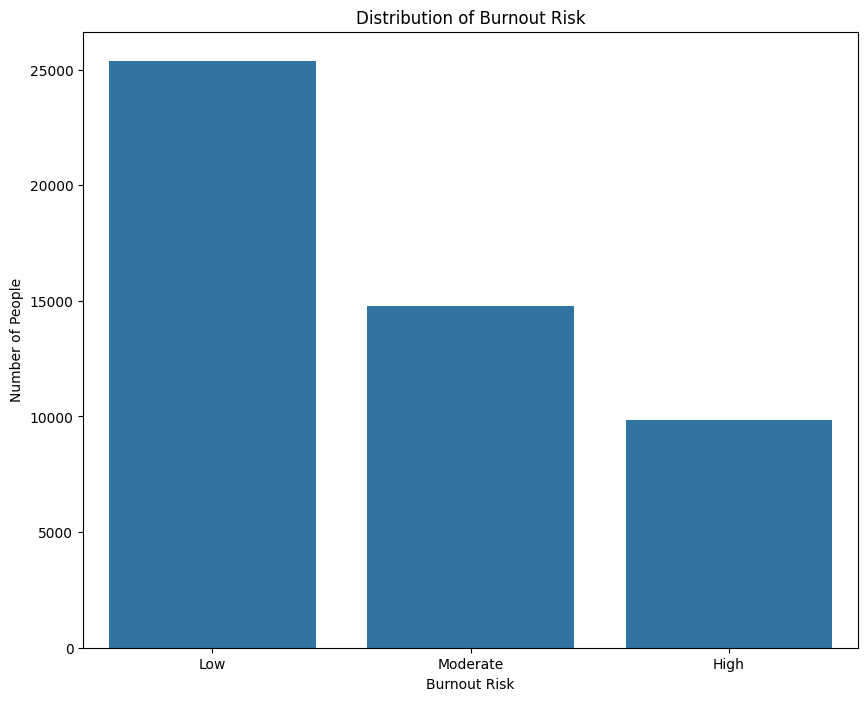

In [15]:
plt.figure(figsize=(10,8))

sns.countplot(data=df, x='Burnout_Risk', order=['Low', 'Moderate', 'High'])
plt.title('Distribution of Burnout Risk')
plt.xlabel('Burnout Risk')
plt.ylabel('Number of People')
plt.show()

The target variable is distributed across three categories: **Low, Moderate, and High**. Low burnout risk is the most common category (50.74%), followed by Moderate (29.56%) and High (19.70%).

The dataset therefore has **moderate class imbalance**, with fewer High-risk observations than Low-risk observations. This will be considered during model evaluation, where metrics such as macro F1-score, precision, recall, and the confusion matrix will provide a more balanced assessment than accuracy alone.


### Other Columns Distribution

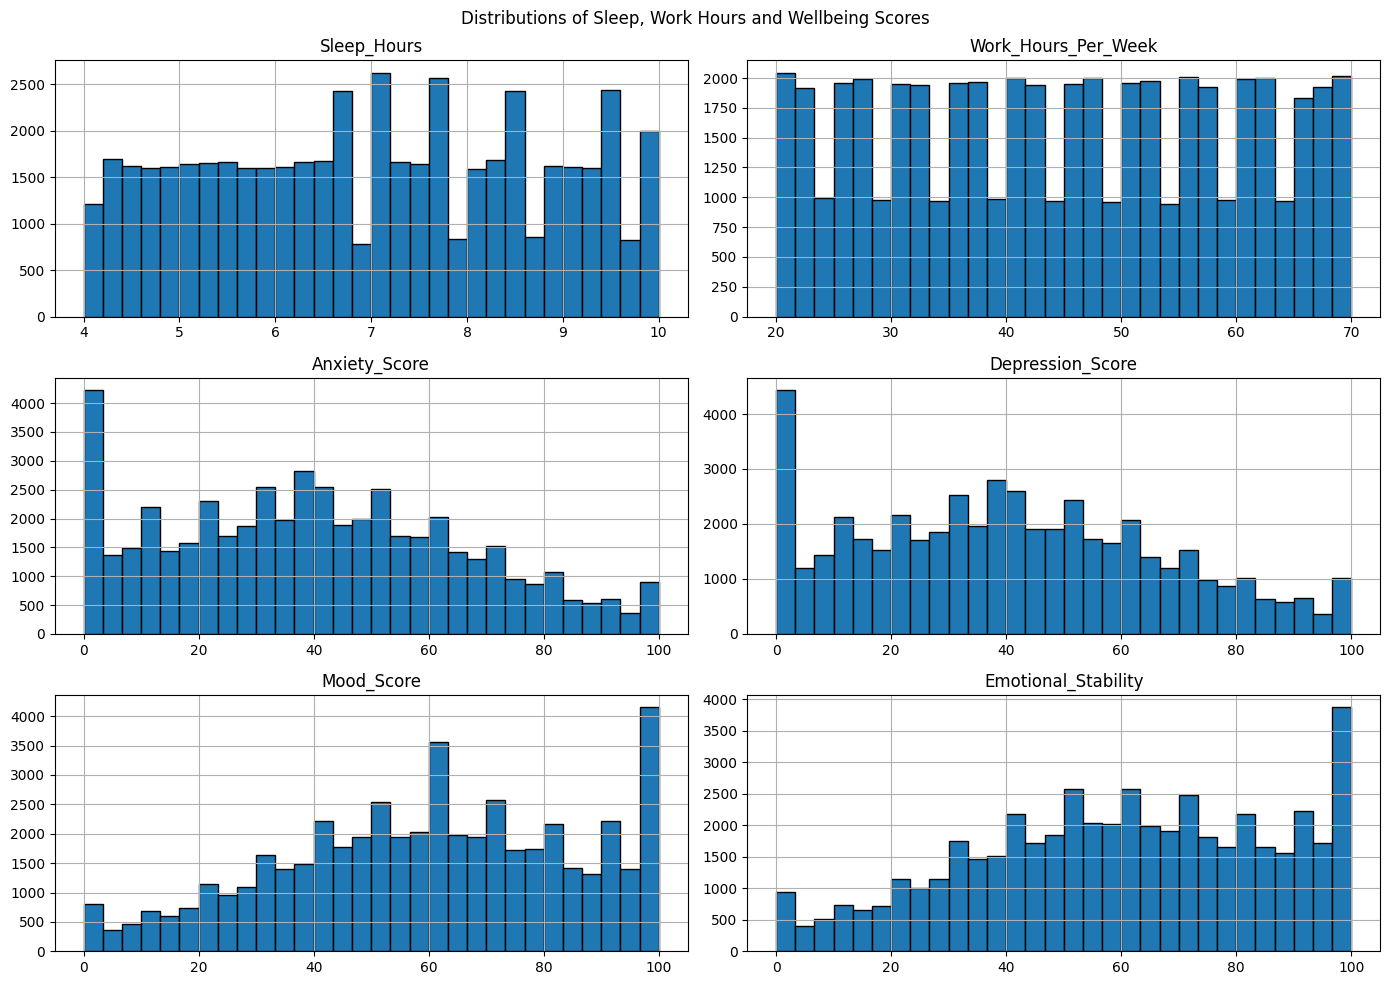

In [16]:
# Numerical
dist_features = ['Sleep_Hours', 'Work_Hours_Per_Week', 'Anxiety_Score', 'Depression_Score', 'Mood_Score', 'Emotional_Stability']

df[dist_features].hist(bins=30, figsize=(14, 10), edgecolor='black')
plt.suptitle('Distributions of Sleep, Work Hours and Wellbeing Scores')
plt.tight_layout()
plt.show()


In [17]:
# Skewness
skewness = df[dist_features].skew().sort_values()
display(skewness.to_frame('skewness'))

,skewness
Emotional_Stability,-0.264588
Mood_Score,-0.253466
Sleep_Hours,-0.001537
Work_Hours_Per_Week,0.002594
Anxiety_Score,0.257150
Depression_Score,0.266881


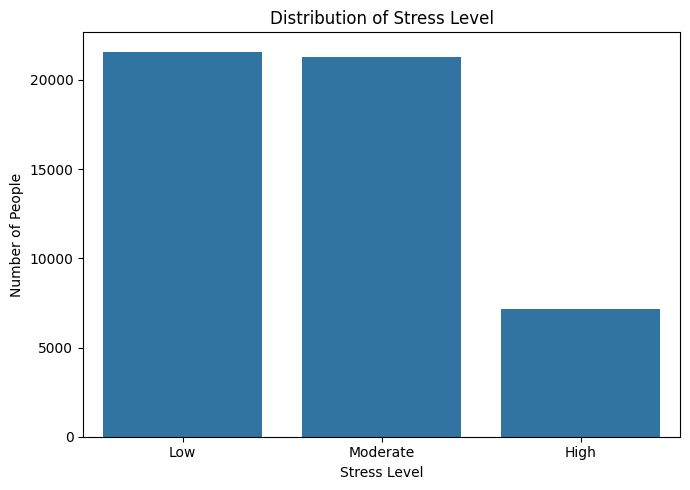

In [18]:
# Stress Level

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x='Stress_Level', order=df['Stress_Level'].value_counts().index)
plt.title('Distribution of Stress Level')
plt.xlabel('Stress Level')
plt.ylabel('Number of People')
plt.tight_layout()
plt.show()

The numerical variables show relatively low skewness, with Sleep_Hours and Work_Hours_Per_Week being almost perfectly symmetric. Anxiety_Score and Depression_Score show slight right skew, while Mood_Score and Emotional_Stability show slight left skew; none exhibits strong skewness requiring immediate transformation. Stress_Level is concentrated in the Low (43.17%) and Moderate (42.53%) categories, while High stress accounts for 14.30% of observations.

### Compare Anxiety_Score, Depression_Score, and Mood_Score across burnout risk groups

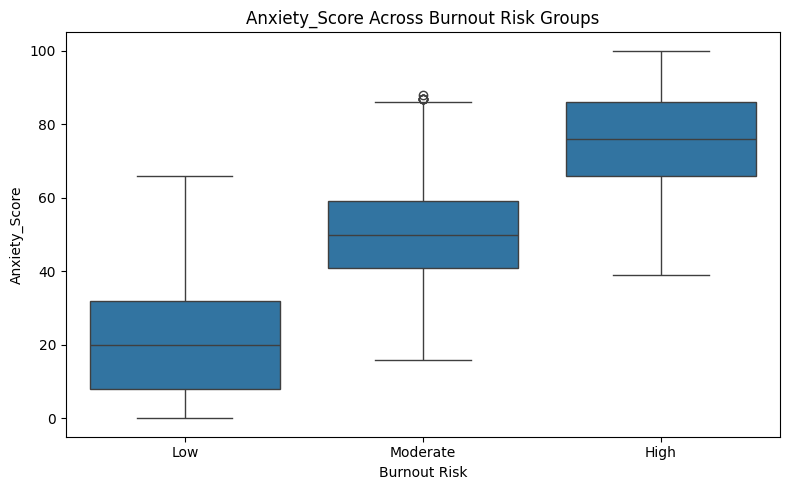

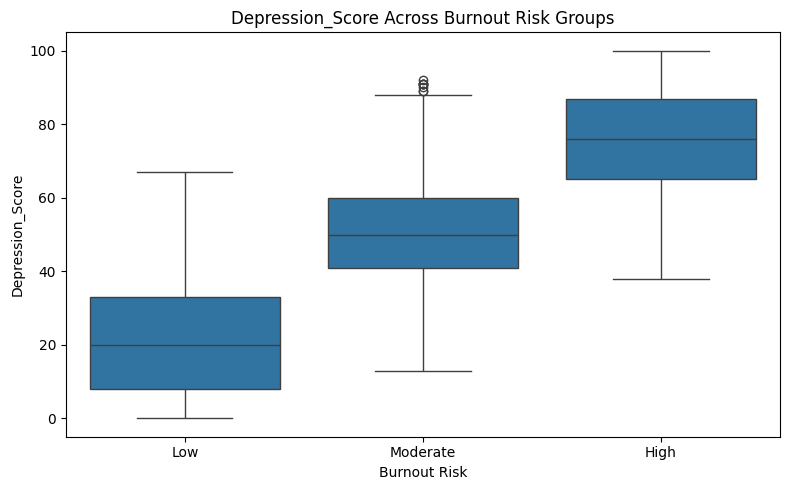

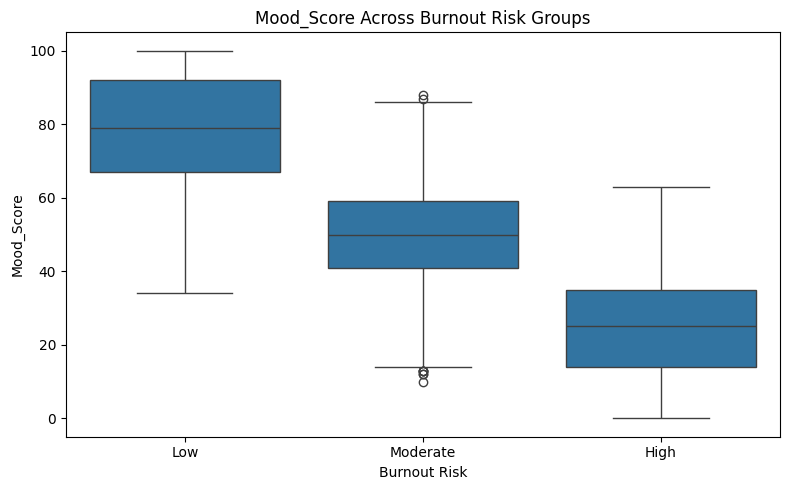

In [19]:
mh_features = ['Anxiety_Score', 'Depression_Score', 'Mood_Score']

for feature in mh_features:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x='Burnout_Risk', y=feature, order=['Low', 'Moderate', 'High'])
    plt.title(f'{feature} Across Burnout Risk Groups')
    plt.xlabel('Burnout Risk')
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()

Anxiety and depression scores show progressively higher median values across burnout-risk groups, with the High-risk group exhibiting the highest scores. In contrast, Mood_Score decreases as burnout risk increases, with the High-risk group showing the lowest median mood score. These patterns indicate strong associations between mental wellbeing measures and burnout risk, although they do not establish causation.

### Compare burnout risk change across Employment_Status, Remote_Work, and Support_System categories

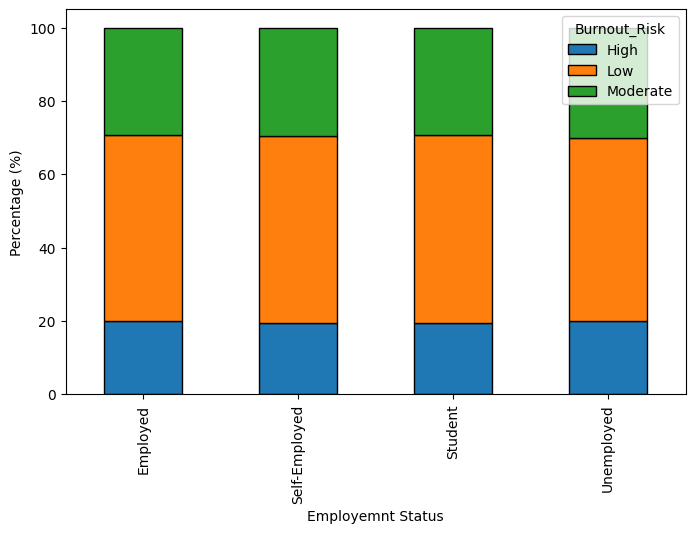

Burnout_Risk,Low,Moderate,High
Employment_Status,,,
Employed,50.716932,29.345900,19.937168
Self-Employed,51.035096,29.427462,19.537441
Student,51.253994,29.297125,19.448882
Unemployed,49.960630,30.157480,19.881890


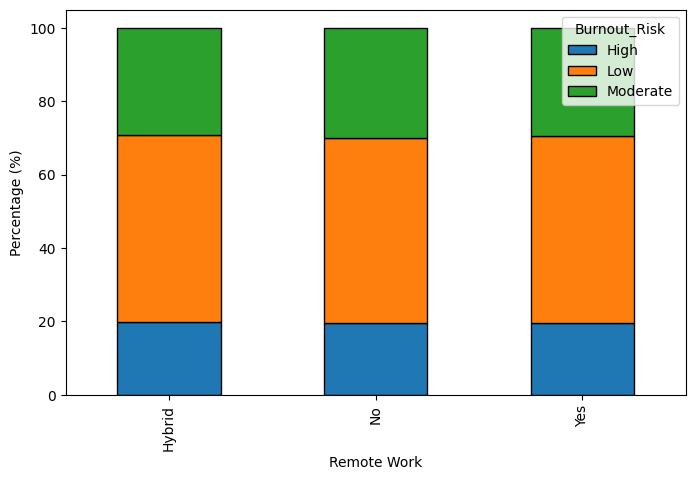

Burnout_Risk,Low,Moderate,High
Remote_Work,,,
Hybrid,50.905602,29.159170,19.935228
No,50.332475,30.000599,19.666926
Yes,50.976973,29.519630,19.503397


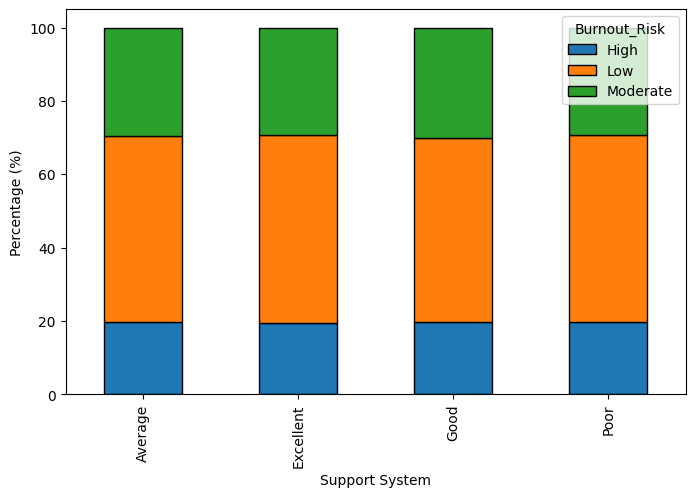

Burnout_Risk,Low,Moderate,High
Support_System,,,
Average,50.702875,29.640575,19.656550
Excellent,51.303997,29.156237,19.539766
Good,50.055955,30.167866,19.776179
Poor,50.893921,29.272944,19.833135


In [20]:
# Employment Status
status = pd.crosstab(df['Employment_Status'], df['Burnout_Risk'], normalize='index')*100
order = ['Low', 'Moderate', 'High']

status.plot(kind='bar', stacked=True, figsize=(8,5), edgecolor='black')
plt.xlabel('Employemnt Status')
plt.ylabel('Percentage (%)')
plt.show()
display(status[order])

# Remote Work
remote = pd.crosstab(df['Remote_Work'], df['Burnout_Risk'], normalize='index')*100

remote.plot(kind='bar', stacked=True, figsize=(8,5), edgecolor='black')
plt.xlabel('Remote Work')
plt.ylabel('Percentage (%)')
plt.show()
display(remote[order])

# Support System
support = pd.crosstab(df['Support_System'], df['Burnout_Risk'], normalize='index')*100

support.plot(kind='bar', stacked=True, figsize=(8,5), edgecolor='black')
plt.xlabel('Support System')
plt.ylabel('Percentage (%)')
plt.show()
display(support[order])


- Employment status does not appear to meaningfully distinguish burnout risk in this dataset.

- Remote-work arrangement appears to have very little association with burnout risk in this dataset.

- Support System shows only a very weak descriptive relationship with burnout risk, with high-risk proportions remaining close to 20% across all categories.

### Work Hours + Sleep Hours

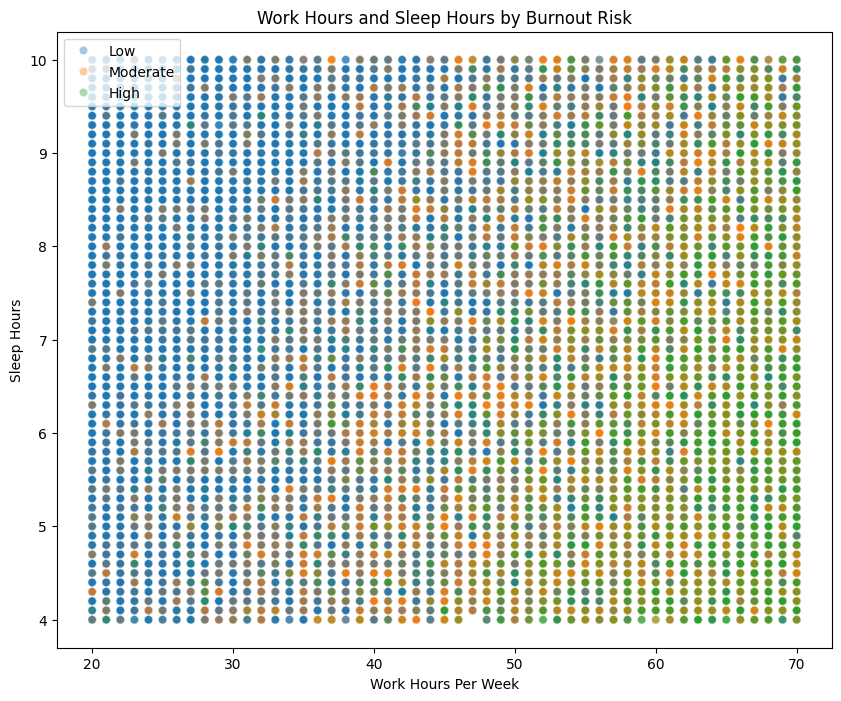

In [21]:
plt.figure(figsize=(10,8))

sns.scatterplot(data=df, x='Work_Hours_Per_Week', y='Sleep_Hours', hue='Burnout_Risk', hue_order=['Low', 'Moderate', 'High'], alpha=0.4 )
plt.title('Work Hours and Sleep Hours by Burnout Risk')
plt.xlabel('Work Hours Per Week')
plt.ylabel('Sleep Hours')
plt.legend()
plt.show()

The scatter plot shows a concentration of high burnout-risk observations among participants reporting longer working hours and fewer hours of sleep. This suggests that workload and sleep duration may jointly be associated with burnout risk.

### A correlation heatmap pattern among the numeric wellbeing scores (Anxiety_Score, Depression_Score, Mood_Score, Life_Satisfaction, Productivity_Score)

In [22]:
corr = df[['Anxiety_Score', 'Depression_Score', 'Mood_Score', 'Life_Satisfaction', 'Productivity_Score']].corr()

display(corr.round(2))



,Anxiety_Score,Depression_Score,Mood_Score,Life_Satisfaction,Productivity_Score
Anxiety_Score,1.00,0.90,-0.92,-0.0,-0.90
Depression_Score,0.90,1.00,-0.91,0.0,-0.88
Mood_Score,-0.92,-0.91,1.00,0.0,0.96
Life_Satisfaction,-0.00,0.00,0.00,1.0,0.00
Productivity_Score,-0.90,-0.88,0.96,0.0,1.00


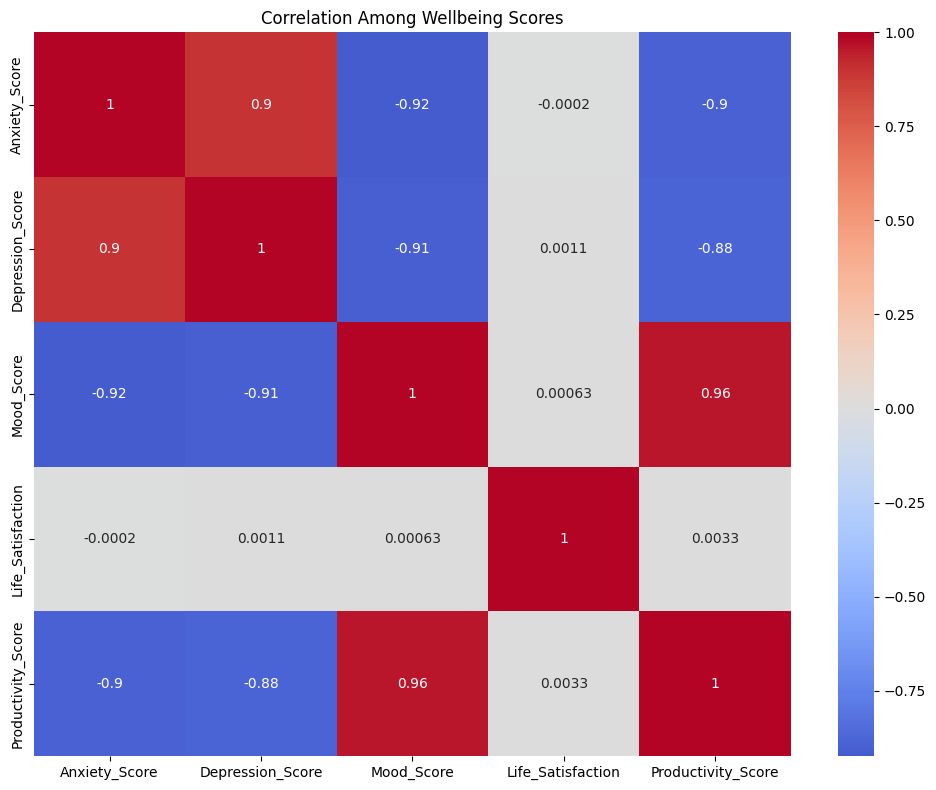

In [23]:
plt.figure(figsize=(10,8))

sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)

plt.title('Correlation Among Wellbeing Scores')
plt.tight_layout()
plt.show()

The correlation analysis revealed strong relationships among several wellbeing measures. Anxiety and depression were strongly positively correlated (r = 0.91), while both showed strong negative relationships with mood, productivity, and related wellbeing measures. Mood and productivity exhibited an exceptionally strong positive correlation (r = 0.97), suggesting substantial information overlap. In contrast, Life_Satisfaction showed near-zero linear correlations with the other selected measures. These relationships indicate potential multicollinearity that should be considered during model development and interpretation.

### Chronic Stress & Family History

In [24]:
# Chronic stress

stress_pct = pd.crosstab(df['Chronic_Stress'], df['Burnout_Risk'], normalize='index') * 100

display(stress_pct[order])

Burnout_Risk,Low,Moderate,High
Chronic_Stress,,,
No,58.640377,32.885673,8.473949
Yes,0.000000,8.207183,91.792817


In [25]:
# Family History
family_pct = pd.crosstab(df['Family_History_Mental_Illness'], df['Burnout_Risk'], normalize='index') * 100
display(family_pct[order])

Burnout_Risk,Low,Moderate,High
Family_History_Mental_Illness,,,
No,50.962880,29.480483,19.556636
Yes,50.511658,29.640034,19.848309


Chronic_Stress showed an exceptionally strong descriptive association with burnout risk: 91.79% of participants reporting chronic stress were classified as High burnout risk, compared with 8.47% among those without chronic stress. In contrast, Family_History_Mental_Illness showed minimal difference, with High-risk proportions of 19.56% and 19.85% for participants reporting no and yes, respectively. The unusually strong relationship between Chronic_Stress and the target warrants further investigation during feature analysis and model interpretation.

### Which features are most associated with Burnout Risk?

The exploratory analysis identified work hours, sleep duration, stress, chronic stress, and several mental-wellbeing measures as potentially important factors associated with burnout risk. Work hours and sleep hours showed significant differences across burnout-risk groups, while Stress_Level and Chronic_Stress were significantly associated with burnout risk. Mental-wellbeing measures also displayed strong relationships with burnout risk, although several of these variables were highly correlated with one another. In contrast, Employment_Status, Remote_Work, Support_System, Job_Satisfaction, Work_Life_Balance, and Family_History_Mental_Illness showed comparatively weak descriptive or statistical associations in the analyses performed.

# Step 6: Split Features and Target, Then Train/Test Split

### Split Features and Target

In [26]:
# Target
y = df['Burnout_Risk']

# Features
X = df.drop(columns=['Person_ID','Burnout_Score', 'Mental_Health_Status', 'AI_Wellness_Recommendation', 'Burnout_Risk'])

print('y shape: ', y.shape)
print('X shape: ', X.shape)

            

y shape:  (50000,)
X shape:  (50000, 35)


### Train/Test Split

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

print('X_train shape: ', X_train.shape)
print('X_test shape: ', X_test.shape)
print('y_train shape: ', y_train.shape)
print('y_test shape: ', y_test.shape)


X_train shape:  (40000, 35)
X_test shape:  (10000, 35)
y_train shape:  (40000,)
y_test shape:  (10000,)


### Identify Numerical and Categorical Features

In [28]:
# Numerical Features
numerical_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

#Categorical Features
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()

print(len(numerical_features))
print(numerical_features)

print(len(categorical_features))
print(categorical_features)

19
['Age', 'Monthly_Income_USD', 'Work_Hours_Per_Week', 'Job_Satisfaction', 'Work_Life_Balance', 'Sleep_Hours', 'Anxiety_Score', 'Depression_Score', 'Mood_Score', 'Emotional_Stability', 'Physical_Activity_Hours', 'Meditation_Minutes', 'Screen_Time_Hours', 'Social_Media_Hours', 'Gaming_Hours', 'Coffee_Cups_Per_Day', 'Life_Satisfaction', 'Productivity_Score', 'Absenteeism_Days']
16
['Gender', 'Country', 'Occupation', 'Education_Level', 'Employment_Status', 'Remote_Work', 'Sleep_Quality', 'Stress_Level', 'Exercise_Frequency', 'Alcohol_Consumption', 'Smoking', 'Healthy_Diet', 'Chronic_Stress', 'Family_History_Mental_Illness', 'Therapy_Attendance', 'Support_System']


### Build the Preprocessing Pipeline

In [29]:
preprocessor = ColumnTransformer([
    ('numerical', StandardScaler(), numerical_features),
    ('Categorical', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

In [30]:
preprocessor

ColumnTransformer(transformers=[('numerical', StandardScaler(),
                                 ['Age', 'Monthly_Income_USD',
                                  'Work_Hours_Per_Week', 'Job_Satisfaction',
                                  'Work_Life_Balance', 'Sleep_Hours',
                                  'Anxiety_Score', 'Depression_Score',
                                  'Mood_Score', 'Emotional_Stability',
                                  'Physical_Activity_Hours',
                                  'Meditation_Minutes', 'Screen_Time_Hours',
                                  'Social_Media_Hours', 'Gaming_Hours',
                                  'Coffee_Cups...
                                  'Productivity_Score', 'Absenteeism_Days']),
                                ('Categorical',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['Gender', 'Country', 'Occupation',
                                  'Education_Level', 'Employment_Status',
                                  'Remote_Work', 'Sleep_Quality',
                                  'Stress_Level', 'Exercise_Frequency',
                                  'Alcohol_Consumption', 'Smoking',
                                  'Healthy_Diet', 'Chronic_Stress',
                                  'Family_History_Mental_Illness',
                                  'Therapy_Attendance', 'Support_System'])])

### Fit and Transform the Data

In [31]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(X_train_processed.shape)
print(X_test_processed.shape)

(40000, 107)
(10000, 107)


# Step 7: Train Several Models with Cross-Validation
## Model Training

### Establish the Baseline

In [32]:
baseline_accuracy = y_train.value_counts(normalize=True).max()
print(baseline_accuracy)

0.507375


In [33]:
baseline_model = DummyClassifier(strategy='most_frequent')
baseline_model.fit(X_train, y_train)
baseline_predictions = baseline_model.predict(X_test)
baseline_accuracy = accuracy_score(y_test, baseline_predictions)
print(f'Baseline taet Accuracy: {baseline_accuracy:.2%}')

Baseline taet Accuracy: 50.74%


### 5-Fold Cross-Validation

In [34]:
# Create Models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

### Define evaluation metrics

In [35]:
scoring = {
    'accuracy': 'accuracy',
    'precision_macro': 'precision_macro',
    'recall_macro' : 'recall_macro',
    'f1_macro': 'f1_macro'
}

### Run 5-fold cross-validation

In [36]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

for name, model in models.items():
     scores = cross_validate(
         model, 
         X_train_processed, y_train, 
         cv=cv, 
         scoring=scoring,
         n_jobs=-1
     )
     
     cv_results.append({
        'Model': name,
        'Accuracy': scores['test_accuracy'].mean(),
        'Precision': scores['test_precision_macro'].mean(),
        'Recall': scores['test_recall_macro'].mean(),
        'F1 Macro': scores['test_f1_macro'].mean()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values('F1 Macro', ascending=False)
display(cv_results_df)

,Model,Accuracy,Precision,Recall,F1 Macro
0,Logistic Regression,0.814200,0.799616,0.791041,0.794792
4,Gradient Boosting,0.811975,0.798808,0.791398,0.794326
2,Random Forest,0.812200,0.803040,0.788987,0.794073
3,K-Nearest Neighbors,0.767050,0.746358,0.738379,0.742006
1,Decision Tree,0.749775,0.723764,0.723771,0.723687


### Evaluate Models on the Untouched Test Set

In [37]:
test_results = []

for name, model in models.items():
    model.fit(X_train_processed, y_train)
    
    predictions = model.predict(X_test_processed)
    
    test_results.append({
        'model': name,
        'accuracy': accuracy_score(y_test, predictions),
        'precision': precision_score(y_test, predictions, average='macro'),
        'recall': recall_score(y_test, predictions, average='macro'),
        'f1_macro': f1_score(y_test, predictions, average='macro')
    })

test_results_df = (pd.DataFrame(test_results).sort_values('f1_macro', ascending=False).reset_index(drop=True))

display(test_results_df.round(4))


,model,accuracy,precision,recall,f1_macro
0,Logistic Regression,0.8182,0.8037,0.7955,0.7992
1,Gradient Boosting,0.8161,0.8022,0.7955,0.7982
2,Random Forest,0.8154,0.8059,0.7911,0.7967
3,K-Nearest Neighbors,0.7760,0.7571,0.7466,0.7514
4,Decision Tree,0.7532,0.7272,0.7282,0.7277


### Classification Report

In [38]:
# Logistic Regression Model

logistic_model = models['Logistic Regression']

logistic_model.fit(X_train_processed, y_train)

logistic_predictions = logistic_model.predict(X_test_processed)

print(classification_report(y_test, logistic_predictions, target_names=['High','Low', 'Moderate']))

              precision    recall  f1-score   support

        High       0.83      0.78      0.80      1970
         Low       0.90      0.89      0.89      5074
    Moderate       0.68      0.72      0.70      2956

    accuracy                           0.82     10000
   macro avg       0.80      0.80      0.80     10000
weighted avg       0.82      0.82      0.82     10000



Logistic Regression achieved 81.82% accuracy and a macro F1-score of 0.799 on the held-out test set. Performance was strongest for Low burnout risk (F1 = 0.89), followed by High risk (F1 = 0.80), while Moderate risk was more difficult to classify (F1 = 0.70). The model achieved 78% recall for High-risk observations, indicating that most—but not all—high-risk cases were identified.

In [39]:
all_test_results = []
classification_reports = {}

for name, model in models.items():

    model.fit(X_train_processed, y_train)
    
    predictions = model.predict(X_test_processed)
    
    all_test_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, predictions),
        'Precision': precision_score(y_test, predictions, average='macro'),
        'Recall': recall_score(y_test, predictions, average = 'macro'),
        'F1 Macro': f1_score(y_test, predictions, average = 'macro')
    })
    
    classification_reports[name] = classification_report(
        y_test, predictions, output_dict=True
    )
    
all_tests_results_df = (pd.DataFrame(all_test_results).sort_values('F1 Macro', ascending=False).reset_index(drop=True))

display(all_tests_results_df.round(4))    

,Model,Accuracy,Precision,Recall,F1 Macro
0,Logistic Regression,0.8182,0.8037,0.7955,0.7992
1,Gradient Boosting,0.8161,0.8022,0.7955,0.7982
2,Random Forest,0.8154,0.8059,0.7911,0.7967
3,K-Nearest Neighbors,0.7760,0.7571,0.7466,0.7514
4,Decision Tree,0.7532,0.7272,0.7282,0.7277


In [40]:
class_comparison = []

for model_name, report in classification_reports.items():
     for class_name in ['Low', 'Moderate', 'High']:
         class_comparison.append({
             'Model': model_name,
             'Class': class_name,
             'Precision': report[class_name]['precision'],
             'Recall': report[class_name]['recall'],
             'F1': report[class_name]['f1-score']
         })

class_comparison_df = pd.DataFrame(class_comparison)

display(class_comparison_df.round(4))

,Model,Class,Precision,Recall,F1
0,Logistic Regression,Low,0.8952,0.8940,0.8946
1,Logistic Regression,Moderate,0.6839,0.7158,0.6995
2,Logistic Regression,High,0.8320,0.7766,0.8034
3,Decision Tree,Low,0.8504,0.8571,0.8537
4,Decision Tree,Moderate,0.5887,0.5761,0.5823
5,Decision Tree,High,0.7426,0.7513,0.7469
6,Random Forest,Low,0.9005,0.8845,0.8924
7,Random Forest,Moderate,0.6690,0.7432,0.7042
8,Random Forest,High,0.8482,0.7457,0.7936
9,K-Nearest Neighbors,Low,0.8631,0.8733,0.8681


All five models substantially outperformed the majority-class baseline. Logistic Regression, Gradient Boosting, and Random Forest produced similar test performance, with macro F1 scores of 0.799, 0.798, and 0.797 respectively. Across models, Low burnout risk was classified most accurately, while Moderate burnout risk was consistently the most difficult class to distinguish. The leading models achieved approximately 0.80 F1 for High-risk observations, indicating reasonably strong identification of the highest-risk group while still leaving room for missed cases.

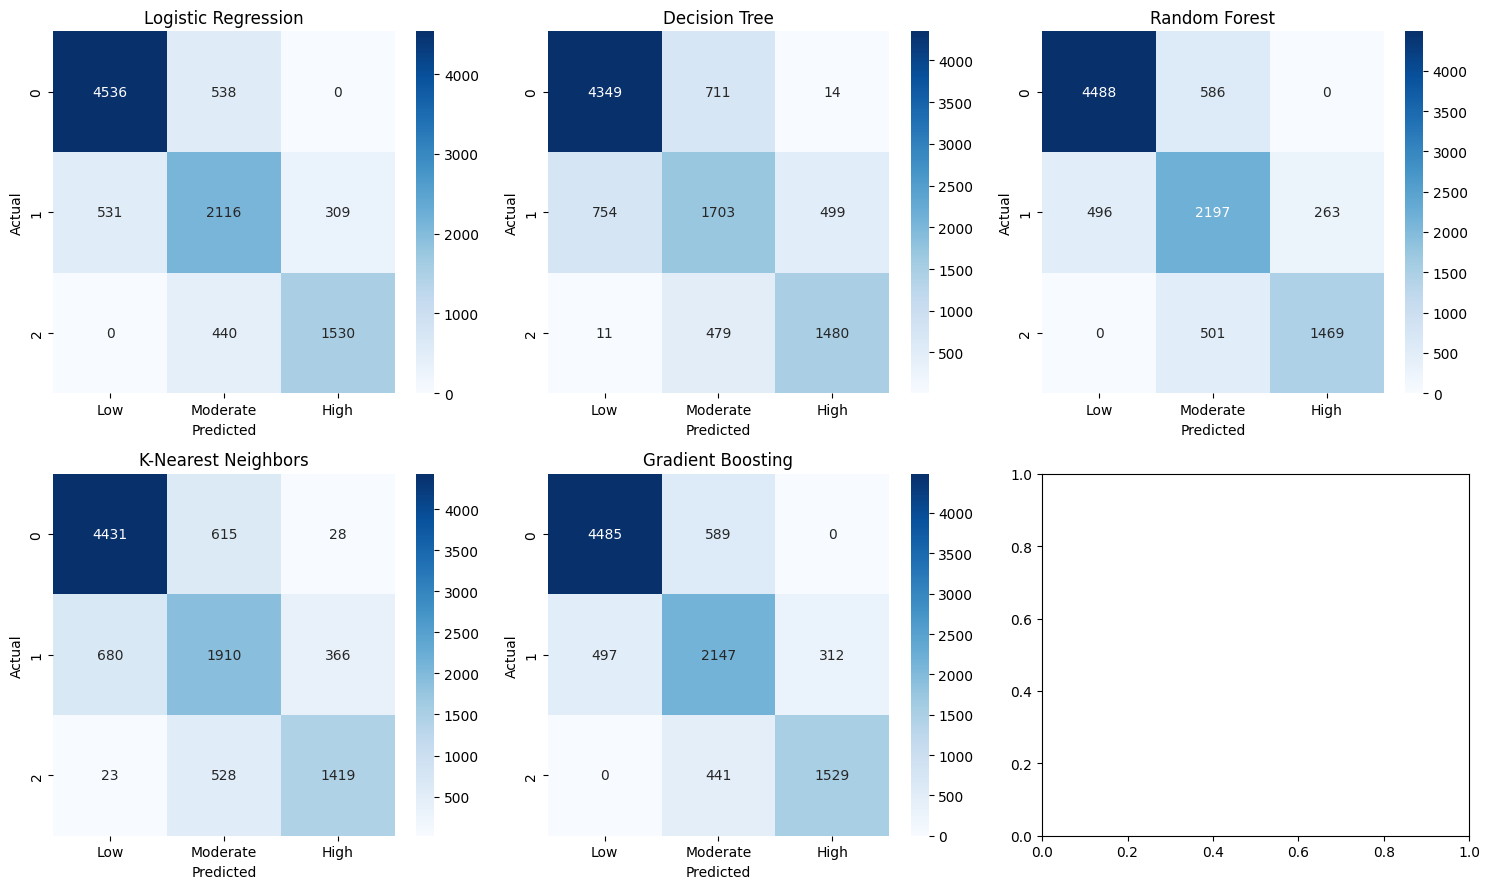

In [41]:
class_labels = ['Low', 'Moderate', 'High']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, (name, model) in zip(axes.flat, models.items()):
    
    predictions = model.predict(X_test_processed)
    cm = confusion_matrix(y_test, predictions, labels=class_labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    
plt.tight_layout()
plt.show()



Confusion matrix analysis showed that the leading models primarily confused adjacent burnout-risk categories rather than making extreme Low-to-High or High-to-Low errors. Logistic Regression, Gradient Boosting and Random Forest made no direct High-to-Low or Low-to-High predictions on the test set. The main classification challenge was distinguishing Moderate-risk observations from Low and High risk. This pattern was reflected in the lower Moderate-class F1 scores across the models.

# Step 8: Hyperparameter Tuning.

In [42]:
# Logistic Regression
logistic_param_grid = {
    'C': [0.1, 1, 10],
    'solver': ['lbfgs']
}

logistic_grid = GridSearchCV(
    estimator = LogisticRegression(max_iter=1000,random_state=42),
    param_grid = logistic_param_grid, 
    scoring = 'f1_macro',
    cv = cv,
    n_jobs = -1
)
logistic_grid.fit(X_train_processed, y_train)

# Gradient Boosting
gradient_param_grid = {
    'n_estimators': [100, 150],
    'learning_rate': [0.05, 0.1],
    'max_depth': [2, 3]
}

gradient_grid = GridSearchCV(
    estimator = GradientBoostingClassifier(random_state = 42),
    param_grid = gradient_param_grid,
    scoring = 'f1_macro',
    cv = cv,
    n_jobs = -1
)

gradient_grid.fit(X_train_processed, y_train)

# Results

print('Logistic Regression')
print('Best parameters:', logistic_grid.best_params_)
print('Best CV Macro F1:', round(logistic_grid.best_score_, 4))

print('\n Gradient Boosting')
print('Best parameters:', gradient_grid.best_params_)
print('Best CV Macro F1:', round(gradient_grid.best_score_, 4))



Logistic Regression
Best parameters: {'C': 10, 'solver': 'lbfgs'}
Best CV Macro F1: 0.7949

 Gradient Boosting
Best parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Best CV Macro F1: 0.7971


## Final Test Evaluation

In [44]:
tuned_models = {
    'Tuned Logistic regression': logistic_grid.best_estimator_,
    'Tuned Gradient Boosting': gradient_grid.best_estimator_
}

final_results = []

for name, model in tuned_models.items():
    
    predictions = model.predict(X_test_processed)
    
    final_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, predictions),
        'Precision': precision_score(y_test, predictions, average='macro'),
        'Recall': recall_score(y_test, predictions, average='macro'),
        'F1 Macro': f1_score(y_test, predictions, average='macro')
    })

final_results_df = (pd.DataFrame(final_results).sort_values('F1 Macro', ascending=False).reset_index(drop=True))

display(final_results_df.round(4))

,Model,Accuracy,Precision,Recall,F1 Macro
0,Tuned Gradient Boosting,0.8180,0.8051,0.7984,0.8011
1,Tuned Logistic regression,0.8187,0.8041,0.7962,0.7997


After hyperparameter tuning, Gradient Boosting achieved the highest Macro F1 (0.8011), while Logistic Regression achieved marginally higher accuracy (81.87%). The two models performed very similarly, with Gradient Boosting showing a small advantage in balanced class-level performance.

# Final Model Confusion Matrix

Text(58.222222222222214, 0.5, 'Actual Burnout Risk')

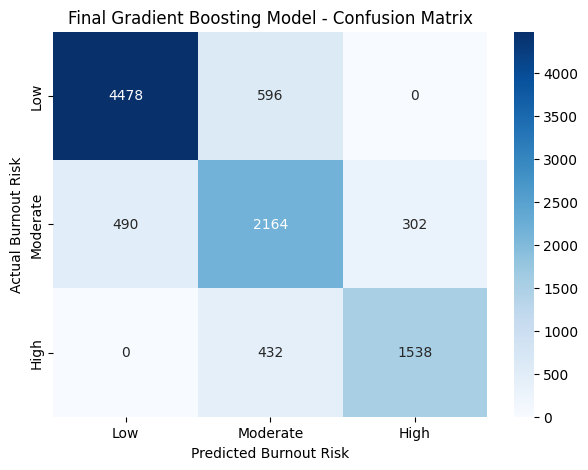

In [46]:
# final Tuned Model
final_model = gradient_grid.best_estimator_

# Predictions on Test test
final_predictions = final_model.predict(X_test_processed)

# Confusion Matrix
class_labels = ['Low', 'Moderate', 'High']

cm_final = confusion_matrix(
    y_test,
    predictions,
    labels=class_labels
)

plt.figure(figsize = (7, 5))

sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues', xticklabels = class_labels, yticklabels = class_labels)

plt.title('Final Gradient Boosting Model - Confusion Matrix')
plt.xlabel('Predicted Burnout Risk')
plt.ylabel('Actual Burnout Risk')

In [48]:
print(classification_report(y_test, final_predictions, labels=["Low", "Moderate", "High"], target_names=["Low", "Moderate", "High"]))

              precision    recall  f1-score   support

         Low       0.90      0.88      0.89      5074
    Moderate       0.68      0.73      0.70      2956
        High       0.84      0.78      0.81      1970

    accuracy                           0.82     10000
   macro avg       0.81      0.80      0.80     10000
weighted avg       0.82      0.82      0.82     10000

